<a href="https://colab.research.google.com/github/saran2007s/RD-INFRO-TECHNOLOGY/blob/main/Titanic_survival_prediction_using_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TITANIC SURVIVAL PREDICTION USING LOGISTIC REGRESSION

Importing required librarys

In [ ]:
# Importing essential libraries
import numpy as np                    # for numerical operations
import pandas as pd                   # for data manipulation
import matplotlib.pyplot as plt       # for plotting graphs
import seaborn as sns                 # for advanced visualizations

# Machine Learning libraries
from sklearn.model_selection import train_test_split    # for splitting the dataset
from sklearn.linear_model import LogisticRegression     # for building the logistic regression model
from sklearn.metrics import accuracy_score              # for evaluating model performance
from sklearn.metrics import classification_report, confusion_matrix # for visualizing model report


## DATA COLLECTION

We begin by importing the Titanic dataset. This dataset contains information about the passengers such as age, gender, ticket class, and whether or not they survived the Titanic disaster.

In [ ]:
# Load the dataset from a CSV file into a pandas DataFrame
titanic_data = pd.read_csv('/content/tested.csv')

In [ ]:
# Display the first five rows of the dataset to understand the structure
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
# Display the number of rows and columns in the dataset
titanic_data.shape

(418, 12)

In [ ]:
# Display concise summary including column data types and non-null values
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
# Check for missing values in each column
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


## Handling the missing values

Missing data can affect model performance. In this section, we address missing values using appropriate techniques such as imputation or column removal.


In [ ]:
# Drop the 'Cabin' column due to high percentage of missing values
titanic_data = titanic_data.drop(columns = 'Cabin' , axis = 1)

In [ ]:
# Replace missing values in the 'Age' column with the mean age
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)

/tmp/ipython-input-59-1647961800.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)


In [ ]:
# Identify the mode of the 'Fare' column for imputation
print(titanic_data['Fare'].mode())

0    7.75
Name: Fare, dtype: float64


In [ ]:
# Replace missing values in the 'Fare' column with the mode
titanic_data['Fare'].fillna(titanic_data['Fare'].mode()[0], inplace= True)


/tmp/ipython-input-61-4197998990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Fare'].fillna(titanic_data['Fare'].mode()[0], inplace= True)


In [ ]:
# Confirm that all missing values have been handled
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Exploratory Data Analysis (EDA)

To understand the dataset better, we begin with some descriptive statistics and basic value counts. This helps us form hypotheses and detect potential issues before model building.


In [ ]:
# Display summary statistics of numerical columns
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.560497
std,120.810458,0.481622,0.841838,12.634534,0.896760,0.981429,55.857145
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,30.272590,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.471875
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
# Count of passengers who survived and did not survive
titanic_data['Survived'].value_counts()

,count
Survived,
0,266
1,152


## DATA VISUALIZATION

We use visualizations to gain further insights into the distribution of features and their relationships with survival.


In [ ]:
# Set Seaborn theme for better aesthetics
sns.set()

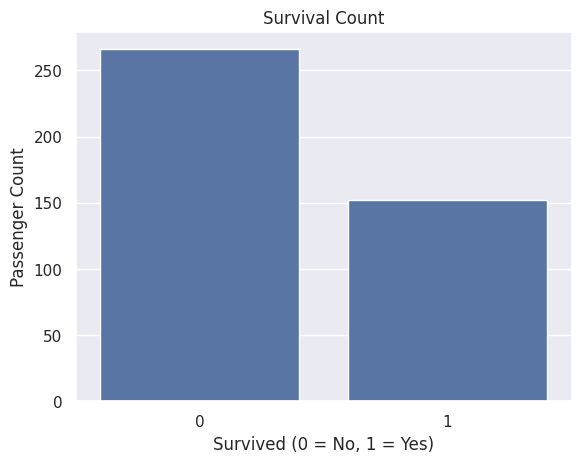

In [ ]:
# visuallizing survival using count plot
sns.countplot(x ='Survived' , data = titanic_data)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Passenger Count')
plt.show()

In [ ]:
# Check distribution of gender in the dataset
titanic_data['Sex'].value_counts()

,count
Sex,
male,266
female,152


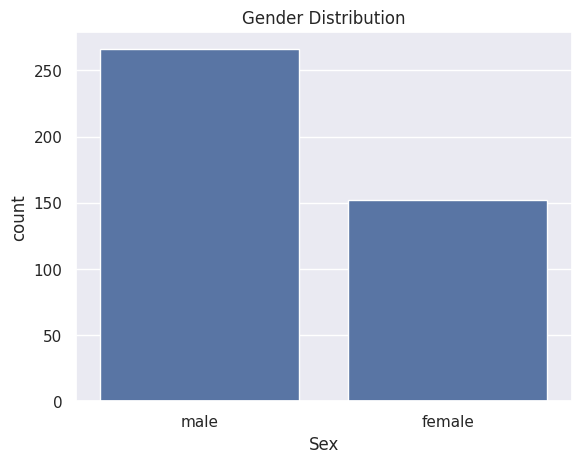

In [ ]:
# Plot count of passengers by gender
sns.countplot(x ='Sex' , data = titanic_data)
plt.title('Gender Distribution')
plt.show()

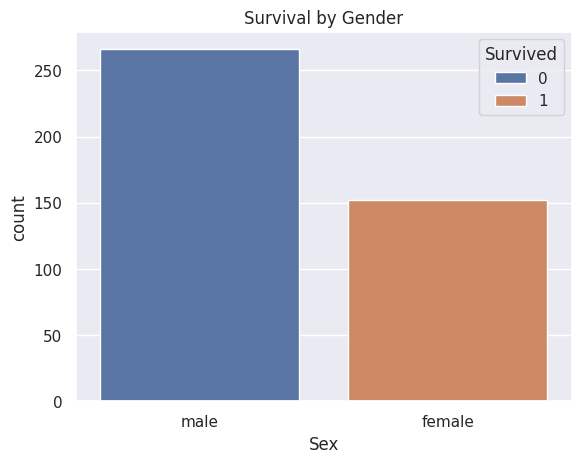

In [ ]:
# Plot survival counts based on gender
sns.countplot(x = 'Sex' , hue = 'Survived' , data = titanic_data)
plt.title('Survival by Gender')
plt.show()

In [ ]:
# Check distribution of passengers by ticket class
titanic_data['Pclass'].value_counts()

,count
Pclass,
3,218
1,107
2,93


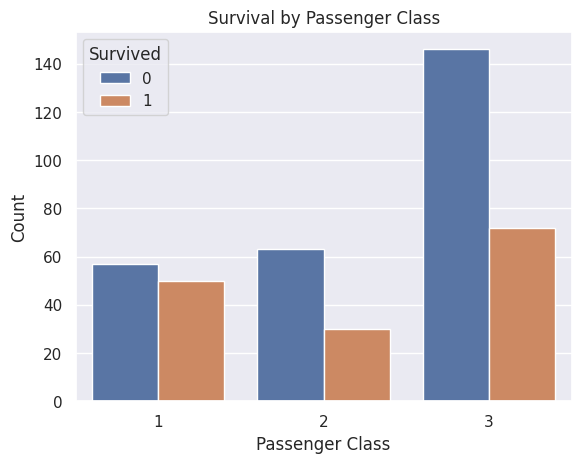

In [ ]:
# Plot survival counts based on passenger class
sns.countplot(x='Pclass', hue='Survived', data=titanic_data)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

## Encoding Categorical Features


Machine learning models require all inputs to be numeric. In this section, we convert categorical columns such as 'Sex' and 'Embarked' into numerical format using label encoding.


In [ ]:
# View unique values in 'Sex' column
titanic_data['Sex'].value_counts()

,count
Sex,
male,266
female,152


In [ ]:
# View unique values in 'Embarked' column
titanic_data['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


In [ ]:
# Convert categorical variables to numerical using dictionary mapping
titanic_data.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}}, inplace=True)


/tmp/ipython-input-74-1756742404.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({'Sex':{'male':0,'female':1}, 'Embarked':{'S':0,'C':1,'Q':2}}, inplace=True)


In [ ]:
# Preview the transformed dataset
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,2
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,0
2,894,0,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,2
3,895,0,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,0


## Feature Selection

We separate the features (independent variables) and the target (dependent variable — `Survived`). Irrelevant columns such as `PassengerId`, `Name`, and `Ticket` are dropped.


In [ ]:
# Drop irrelevant columns and separate features and target
x = titanic_data.drop(columns = ['PassengerId','Name','Ticket','Survived'],axis=1)
y = titanic_data['Survived']

In [ ]:
# Display the features and target
print("Features:\n", x.head())
print("\nTarget:\n", y.head())

Features:
    Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    0  34.5      0      0   7.8292         2
1       3    1  47.0      1      0   7.0000         0
2       2    0  62.0      0      0   9.6875         2
3       3    0  27.0      0      0   8.6625         0
4       3    1  22.0      1      1  12.2875         0

Target:
 0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64


## Splitting the Dataset

We split the dataset into training and testing sets to evaluate the model's performance. Typically, 80% is used for training and 20% for testing.

In [ ]:
# Splitting the data into training and testing sets
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state= 2)

In [ ]:
# Check the shape of the resulting datasets
print("Original dataset shape:", x.shape)
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Original dataset shape: (418, 7)
Training set shape: (334, 7)
Testing set shape: (84, 7)


## Model Training

We will now train a Logistic Regression model using the training dataset.

In [ ]:
# Initialize the Logistic Regression model
model = LogisticRegression()

In [ ]:
# Train the logistic regression model using training data
model.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Model Evaluation

We evaluate our model's performance on both the training and testing datasets using accuracy, confusion matrix, and classification report.

### accuracy score

In [ ]:
# accuracy on training data
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(y_train,x_train_prediction)

In [ ]:
print(x_train_prediction)

[1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 1 0
 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0
 0 0 1 1 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 1 1
 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1
 0 1 1 1 1 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 0 0 1 1 1
 1]


In [ ]:
print('Accuracy on training data : ' , training_data_accuracy)

Accuracy on training data :  1.0


In [ ]:
# accuracy on test data
x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(y_test,x_test_prediction)

In [ ]:
print(x_test_prediction)

[0 0 0 1 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 1
 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0
 0 1 1 0 1 0 0 0 0 0]


In [ ]:
print('Accuracy on test data : ' , test_data_accuracy)


Accuracy on test data :  1.0


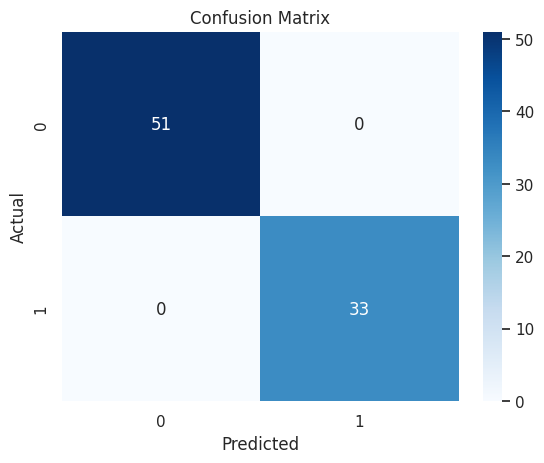

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        33

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [ ]:


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, x_test_prediction)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, x_test_prediction))

In [ ]:
# Save the trained model using joblib
import joblib
joblib.dump(model, 'titanic_survival_model.pkl')
print("Model saved as titanic_survival_model.pkl")

Model saved as titanic_survival_model.pkl


## Conclusion

In this project, we built a logistic regression model to predict passenger survival from the Titanic dataset.

- We performed data cleaning and exploratory data analysis (EDA).
- Categorical features were encoded, and irrelevant features were removed.
- We trained the model using an 80/20 train-test split and achieved competitive accuracy.
- The confusion matrix and classification report showed that the model performs reasonably well, particularly in identifying survivors.

This notebook demonstrates a complete machine learning workflow and can be extended further by applying more advanced models like Random Forests or XGBoost, performing hyperparameter tuning, and deploying the model via Flask or Streamlit.
